# 第 2 周 a｜描述性分析：Table 1、社会经济梯度与发病率

> **本周怎么学**：先学这份精讲，再做 `w02b_eda.ipynb`（工程实践：只在**训练集**上做基线描述，理解为什么描述统计也要先划分数据）。

**这一节学什么**
- 做一张医学论文标准的 **Table 1**（基线特征表），并导出为 CSV
- 按**社会经济劣势（IRSD）**分层，看风险因素和结局有没有"梯度"
- 从"事件比例"升级到**人年发病率**，并计算 95% 置信区间

**用到的数据**：Data Asset 1（干净版）

**前置**：第 1 周（a、b）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())  # 向上找项目根目录
sys.path.insert(0, str(ROOT))

from primecvd import paths                 # 数据与输出路径（primecvd/paths.py）
from primecvd import pubplot as pp         # 顶刊风格作图工具箱（值得通读：primecvd/pubplot.py）
pp.setup()

df = pd.read_csv(paths.ASSET1)
print(df.shape)

(50000, 12)


## 1. 什么是 Table 1？

几乎每篇临床研究论文的第一张表都是 **Table 1**，它描述研究人群的基线特征，一般按暴露或结局分组：

- **连续变量**：均值（标准差），分布偏态时用中位数 [四分位间距]
- **分类变量**：人数（百分比）
- 最后一列常附上组间比较的 P 值

下面先写几个小函数，每个函数负责把一列数据"格式化"成表格里的一个格子。

In [2]:
def mean_sd(x):
    """连续变量 → '均值 (标准差)'"""
    return f"{x.mean():.1f} ({x.std():.1f})"


def median_iqr(x):
    """偏态连续变量 → '中位数 [P25, P75]'"""
    q1, q2, q3 = x.quantile([0.25, 0.50, 0.75])
    return f"{q2:.1f} [{q1:.1f}, {q3:.1f}]"


def n_pct(x):
    """0/1 变量 → '人数 (百分比%)'"""
    return f"{int(x.sum()):,} ({x.mean() * 100:.1f}%)"


def format_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"


# 试一下
print(mean_sd(df["Age"]), "|", median_iqr(df["HbA1c"]), "|", n_pct(df["diabetes"]))

49.7 (12.4) | 4.7 [4.2, 5.1] | 3,717 (7.4%)


## 2. 按是否发生 CVD 事件分组的 Table 1

思路：先定义三个"组"（全部、无事件、有事件），然后对每个变量逐行填表。

P 值的计算方法：
- 近似正态的连续变量：**t 检验**（Welch 版本，不要求两组方差相等）
- 偏态连续变量（HbA1c）：**Mann-Whitney U 检验**（非参数）
- 分类变量：**卡方检验**

In [3]:
groups = {
    "全部": df,
    "无 CVD 事件": df[df["cvd_event"] == 0],
    "有 CVD 事件": df[df["cvd_event"] == 1],
}
no_event, event = groups["无 CVD 事件"], groups["有 CVD 事件"]
rows = []


def add_row(label, formatter, series_getter, p=None):
    """在 Table 1 里加一行：对每个组调用 formatter，并附上 P 值"""
    row = {"变量": label}
    for name, data in groups.items():
        row[name] = formatter(series_getter(data))
    row["P 值"] = format_p(p) if p is not None else ""
    rows.append(row)


# 第一行：人数
rows.append({"变量": "人数", **{k: f"{len(v):,}" for k, v in groups.items()}, "P 值": ""})

# 连续变量（近似正态）→ 均值 (SD) + t 检验
for var, label in [("Age", "年龄，岁"), ("BMI", "BMI，kg/m²"),
                   ("SBP", "收缩压，mmHg"), ("eGFR", "eGFR，mL/min/1.73m²")]:
    p = stats.ttest_ind(no_event[var], event[var], equal_var=False).pvalue
    add_row(f"{label}，均值 (SD)", mean_sd, lambda d, v=var: d[v], p)

# 偏态连续变量 → 中位数 [IQR] + Mann-Whitney U 检验
p = stats.mannwhitneyu(no_event["HbA1c"], event["HbA1c"]).pvalue
add_row("HbA1c，%，中位数 [IQR]", median_iqr, lambda d: d["HbA1c"], p)

# 多分类变量 → 先写一行变量名（带卡方检验 P 值），再逐个类别写 n (%)
for var, label, levels in [
    ("smoking_status", "吸烟状态", {"non": "从不吸烟", "ex": "已戒烟", "current": "现在吸烟"}),
    ("IRSD_quintile", "IRSD 五分位", {1: "1（最贫困）", 2: "2", 3: "3", 4: "4", 5: "5（最富裕）"}),
]:
    p = stats.chi2_contingency(pd.crosstab(df[var], df["cvd_event"])).pvalue
    rows.append({"变量": f"{label}，n (%)", **{k: "" for k in groups}, "P 值": format_p(p)})
    for level, level_label in levels.items():
        add_row(f"    {level_label}", n_pct, lambda d, v=var, l=level: d[v] == l)

# 二分类变量 → n (%) + 卡方检验
for var, label in [("diabetes", "糖尿病"), ("CKD", "慢性肾病"), ("AF", "房颤")]:
    p = stats.chi2_contingency(pd.crosstab(df[var], df["cvd_event"])).pvalue
    add_row(f"{label}，n (%)", n_pct, lambda d, v=var: d[v], p)

table1 = pd.DataFrame(rows).set_index("变量")
table1

,全部,无 CVD 事件,有 CVD 事件,P 值
变量,,,,
人数,"50,000","47,991","2,009",
年龄，岁，均值 (SD),49.7 (12.4),49.2 (12.1),63.0 (11.6),<0.001
BMI，kg/m²，均值 (SD),28.3 (5.0),28.3 (5.0),30.1 (5.0),<0.001
收缩压，mmHg，均值 (SD),123.3 (16.1),122.8 (15.9),136.0 (16.5),<0.001
eGFR，mL/min/1.73m²，均值 (SD),82.8 (6.1),82.9 (6.0),79.4 (7.6),<0.001
HbA1c，%，中位数 [IQR],"4.7 [4.2, 5.1]","4.6 [4.2, 5.1]","6.3 [4.8, 7.8]",<0.001
吸烟状态，n (%),,,,<0.001
从不吸烟,"36,572 (73.1%)","35,258 (73.5%)","1,314 (65.4%)",
已戒烟,"8,361 (16.7%)","7,928 (16.5%)",433 (21.6%),


In [4]:
path = paths.save_table(table1, "02_table1_by_cvd_event")
print("已保存：", path)

已保存： outputs/tables/02_table1_by_cvd_event.csv


**怎么解读这张表**
- 发生 CVD 事件的人**平均大约老 14 岁**、收缩压高约 13 mmHg、糖尿病比例约 60%（无事件组约 5%）
- 几乎所有 P 值都 < 0.001。这**不代表**每个差异都有临床意义：样本有 5 万人，再小的差异也能"显著"。**大样本时要看差异的大小，别只看 P 值。** 比如 eGFR 两组只差约 3.5，临床意义有限
- CKD 和房颤在事件组的比例更高，但病例数很少，估计的不确定性较大

💡 Table 1 描述的是**关联**，不是因果。事件组年龄更大，所以其他变量上的差异有一部分可能只是"年龄"造成的。

## 3. 社会经济梯度：按 IRSD 五分位分层

**IRSD**（Index of Relative Socio-economic Disadvantage）是澳大利亚统计局编制的地区社会经济劣势指数。分成五等份后：**1 = 最贫困的 20% 地区，5 = 最富裕的 20% 地区**。

健康不平等研究关心的问题是：**越贫困的人群，心血管风险是否越高？这种差异是通过什么途径产生的？**

In [5]:
irsd = df.groupby("IRSD_quintile").agg(
    人数=("Age", "size"),
    平均年龄=("Age", "mean"),
    现在吸烟_百分比=("smoking_status", lambda s: (s == "current").mean() * 100),
    平均BMI=("BMI", "mean"),
    糖尿病_百分比=("diabetes", lambda s: s.mean() * 100),
    平均收缩压=("SBP", "mean"),
    CVD事件_百分比=("cvd_event", lambda s: s.mean() * 100),
).round(1)
irsd

,人数,平均年龄,现在吸烟_百分比,平均BMI,糖尿病_百分比,平均收缩压,CVD事件_百分比
IRSD_quintile,,,,,,,
1,10640,49.7,15.4,29.5,8.4,125.0,4.3
2,8055,49.8,12.9,29.0,7.8,124.2,4.4
3,11941,49.7,10.1,28.4,7.5,123.3,4.3
4,8495,49.9,7.4,27.7,7.0,122.6,3.7
5,10869,49.6,5.1,27.1,6.4,121.6,3.4


In [6]:
def wilson_ci(k, n, z=1.96):
    """比例的 95% 置信区间（Wilson 法）：比常见的"p ± 1.96×SE"更准确，比例接近 0 或 1 时也不会越界"""
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return p, centre - half, centre + half


# 计算每个五分位的点估计和 95% CI
g = df.groupby("IRSD_quintile")
estimates = {}
for key, is_yes in [("smoke", lambda d: d["smoking_status"] == "current"),
                    ("diabetes", lambda d: d["diabetes"] == 1),
                    ("cvd", lambda d: d["cvd_event"] == 1)]:
    rows = [(q, *[v * 100 for v in wilson_ci(is_yes(d).sum(), len(d))]) for q, d in g]
    estimates[key] = pd.DataFrame(rows, columns=["q", "est", "lo", "hi"]).set_index("q")
bmi = g["BMI"].agg(["mean", "std", "size"])
se = bmi["std"] / np.sqrt(bmi["size"])
estimates["bmi"] = pd.DataFrame({"est": bmi["mean"], "lo": bmi["mean"] - 1.96 * se,
                                 "hi": bmi["mean"] + 1.96 * se})
estimates["cvd"]

,est,lo,hi
q,,,
1,4.276316,3.908093,4.677544
2,4.382371,3.956654,4.851579
3,4.337995,3.987060,4.718301
4,3.731607,3.349015,4.156027
5,3.367375,3.044379,3.723324


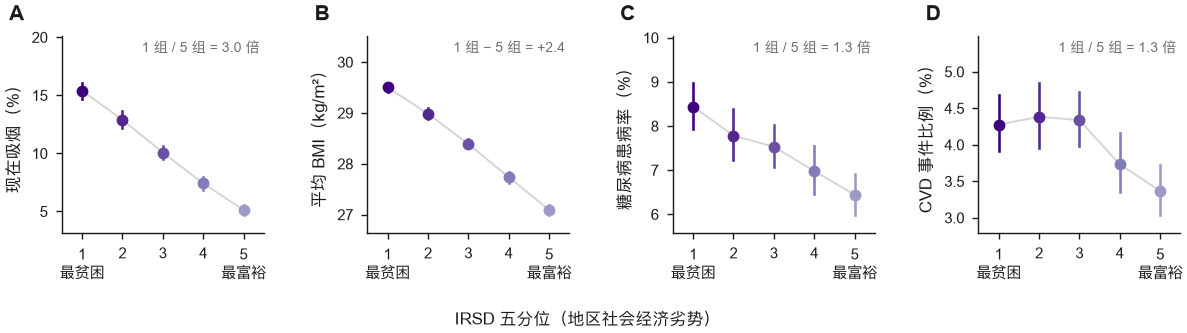

In [7]:
specs = [("smoke", "现在吸烟（%）", "ratio"), ("bmi", "平均 BMI（kg/m²）", "diff"),
         ("diabetes", "糖尿病患病率（%）", "ratio"), ("cvd", "CVD 事件比例（%）", "ratio")]

fig, axes = plt.subplots(1, 4, figsize=pp.size(pp.DOUBLE, 52))
for ax, letter, (key, ylabel, kind) in zip(axes, "ABCD", specs):
    s = estimates[key]
    ax.plot(s.index, s["est"], color=pp.LIGHT, lw=0.8, zorder=1)          # 浅灰连接线：只提示趋势
    for q in s.index:                                                     # 颜色随 IRSD 由深到浅
        ax.plot([q, q], [s.loc[q, "lo"], s.loc[q, "hi"]], color=pp.IRSD[q], lw=1.1, zorder=2)
        ax.plot(q, s.loc[q, "est"], "o", color=pp.IRSD[q], ms=4, zorder=3)
    # 一句话点出结论：最贫困组是最富裕组的几倍（或多多少）
    if kind == "ratio":
        note = f"1 组 / 5 组 = {s.loc[1, 'est'] / s.loc[5, 'est']:.1f} 倍"
    else:
        note = f"1 组 − 5 组 = {s.loc[1, 'est'] - s.loc[5, 'est']:+.1f}"
    ax.text(0.98, 0.98, note, transform=ax.transAxes, ha="right", va="top", fontsize=6, color=pp.GREY)
    ax.set_xticks([1, 2, 3, 4, 5], ["1\n最贫困", "2", "3", "4", "5\n最富裕"])
    ax.set_xlim(0.5, 5.5)
    ax.set_ylabel(ylabel)
    lo, hi = s["lo"].min(), s["hi"].max()
    pad = (hi - lo) * 0.35
    ax.set_ylim(lo - pad * 0.4, hi + pad)
    pp.panel_label(ax, letter)
fig.supxlabel("IRSD 五分位（地区社会经济劣势）", fontsize=7, y=0.02)
fig.tight_layout(w_pad=2.0)
pp.save(fig, "02_irsd_gradient")
plt.show()

**观察**
- 从最富裕（5）到最贫困（1）：现在吸烟比例约**翻三倍**（5% → 15%），平均 BMI 高约 2.4，糖尿病患病率也更高
- CVD 事件比例：最贫困的三组约 4.3–4.4%，最富裕两组降到 3.7% 和 3.4%。总体趋势是越贫困越高，但**不是严格单调**，真实数据也常常这样
- ⚠️ 读图时注意：这四张小图的**纵轴都不从 0 开始**，差异在视觉上被放大了。要判断差异到底有多大，看右上角的倍数 / 差值

🎨 **设计要点**
- **点估计 + 95% CI，而不是柱状图**。柱状图用"长度"表示数值，纵轴必须从 0 开始，否则就是视觉欺骗；点估计用"位置"表示数值，纵轴可以只截取数据所在的范围，但要让读者知道这一点
- **一定要画置信区间**：没有 CI 的点，读者无法判断 4.3% 和 4.4% 的差别是真实差异还是随机波动。比例用 Wilson 法，均值用 ±1.96 × SE
- **有序变量用单色相渐变**：IRSD 从深紫（最贫困）到浅紫（最富裕），和第 5 周 a 的 KM 曲线用同一套颜色
- **一句话点出结论**：右上角的"1 组 / 5 组 = 3.0 倍"让读者不必自己心算
- **四个面板共用一个 x 轴标题**，减少重复

> **图 3｜各 IRSD 五分位的风险因素与 CVD 事件比例。** 点为估计值，竖线为 95% CI（比例用 Wilson 法，均值用正态近似）。右上角为最贫困组（1）与最富裕组（5）之比或之差。纵轴未从 0 开始。
- **各组平均年龄几乎一样**（都在 49–50 岁），所以这个梯度不是"年龄差异"造成的

这正是 PRIME-CVD 论文作业 2 的内容。一个值得思考的问题：贫困本身会不会直接导致 CVD？还是**通过吸烟、肥胖、糖尿病这些中间因素**起作用？第 6 周 a 的 Cox 模型会给出线索。

## 4. 从"比例"到"人年发病率"

第 1 周 a 提到：每个人的随访时间长短不一，所以"事件比例"不够准确。流行病学里更标准的指标是**人年发病率**：

$$\text{发病率} = \frac{\text{事件数}}{\text{总人年数}} \times 1000 \quad （\text{每千人年}）$$

"人年"是把每个人被观察的年数加起来。比如 2 个人各观察 3 年，就贡献 6 人年。

95% 置信区间用**精确 Poisson 法**，通过卡方分布计算：

In [8]:
def incidence_rate(data, by):
    """按 by 分组，计算事件数、人年、每千人年发病率及 95% 置信区间（精确 Poisson 法）"""
    out = data.groupby(by, observed=True).agg(
        人数=("cvd_event", "size"),
        事件数=("cvd_event", "sum"),
        人年=("cvd_time", "sum"),
    )
    k = out["事件数"]
    out["发病率"] = k / out["人年"] * 1000
    out["95%CI下限"] = stats.chi2.ppf(0.025, 2 * k) / 2 / out["人年"] * 1000
    out["95%CI上限"] = stats.chi2.ppf(0.975, 2 * k + 2) / 2 / out["人年"] * 1000
    return out.round({"人年": 0, "发病率": 1, "95%CI下限": 1, "95%CI上限": 1})


incidence_rate(df, "diabetes")

,人数,事件数,人年,发病率,95%CI下限,95%CI上限
diabetes,,,,,,
0,46283,810,224886.0,3.6,3.4,3.9
1,3717,1199,14889.0,80.5,76.0,85.2


糖尿病患者的发病率约为每千人年 80.5 例，非糖尿病者约 3.6 例。

再看**年龄**。先用 `pd.cut()` 把连续的年龄切成几个年龄段：

In [9]:
df["age_group"] = pd.cut(df["Age"], bins=[18, 40, 50, 60, 70, np.inf],
                         labels=["18–39", "40–49", "50–59", "60–69", "70+"],
                         right=False)
# right=False 表示区间"左闭右开"，例如 40 ≤ 年龄 < 50；np.inf 表示正无穷
df["age_group"].value_counts().sort_index()

age_group
18–39    10854
40–49    14746
50–59    14202
60–69     7631
70+       2567
Name: count, dtype: int64

In [10]:
ir_age = incidence_rate(df, "age_group")
ir_age

,人数,事件数,人年,发病率,95%CI下限,95%CI上限
age_group,,,,,,
18–39,10854,51,53088.0,1.0,0.7,1.3
40–49,14746,220,71655.0,3.1,2.7,3.5
50–59,14202,491,68502.0,7.2,6.5,7.8
60–69,7631,681,35572.0,19.1,17.7,20.6
70+,2567,566,10957.0,51.7,47.5,56.1


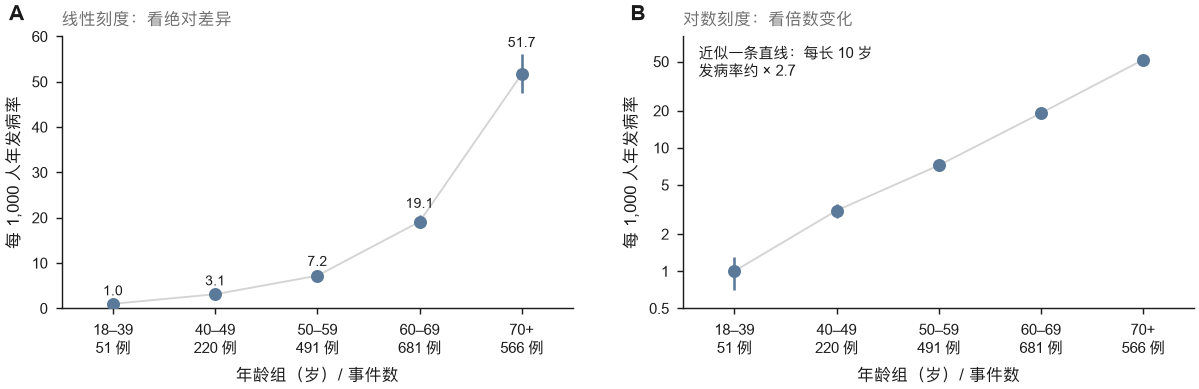

In [11]:
x = np.arange(len(ir_age))
# 刻度标签写两行：年龄组 + 事件数。读者一眼就能看出哪个估计是基于很少的事件得到的
ticklabels = [f"{a}\n{e} 例" for a, e in zip(ir_age.index, ir_age["事件数"])]

fig, axes = plt.subplots(1, 2, figsize=pp.size(pp.DOUBLE, 62))
for ax, letter, log in zip(axes, "AB", [False, True]):
    ax.plot(x, ir_age["发病率"], color=pp.LIGHT, lw=0.8, zorder=1)
    ax.vlines(x, ir_age["95%CI下限"], ir_age["95%CI上限"], color=pp.NEUTRAL, lw=1.1, zorder=2)
    ax.plot(x, ir_age["发病率"], "o", color=pp.NEUTRAL, ms=4.5, zorder=3)
    ax.set_xticks(x, ticklabels)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_xlabel("年龄组（岁）/ 事件数")
    ax.set_ylabel("每 1,000 人年发病率")
    pp.panel_label(ax, letter)
    if not log:                                         # A：线性刻度
        ax.set_ylim(0, 60)
        for xi, rate, hi in zip(x, ir_age["发病率"], ir_age["95%CI上限"]):
            ax.annotate(f"{rate:.1f}", (xi, hi), xytext=(0, 3), textcoords="offset points",
                        ha="center", fontsize=6)
        ax.set_title("线性刻度：看绝对差异", fontweight="normal", color=pp.GREY, fontsize=7)
    else:                                               # B：对数刻度
        ax.set_yscale("log")
        ax.set_ylim(0.5, 80)
        ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50], ["0.5", "1", "2", "5", "10", "20", "50"])
        ax.yaxis.set_minor_locator(plt.NullLocator())
        ratio = (ir_age["发病率"].iloc[-1] / ir_age["发病率"].iloc[0]) ** (1 / (len(x) - 1))
        ax.text(0.03, 0.97, f"近似一条直线：每长 10 岁\n发病率约 × {ratio:.1f}", transform=ax.transAxes,
                ha="left", va="top", fontsize=6.3)
        ax.set_title("对数刻度：看倍数变化", fontweight="normal", color=pp.GREY, fontsize=7)
fig.tight_layout(w_pad=3)
pp.save(fig, "02_incidence_by_age")
plt.show()

**观察**：年龄每大 10 岁，发病率大约变成原来的 **2.5–3 倍**（1.0 → 3.1 → 7.2 → 19.1 → 51.7）。年龄是心血管病最强的风险因素之一，所以之后建模时**一定要调整年龄**。

置信区间越窄，估计越精确。区间宽窄主要取决于**事件数**，而不是人数：
- 18–39 岁虽然有 1 万多人，但只有 51 个事件，区间 0.7–1.3，相对浮动约 ±30%
- 70+ 岁的区间在图 A 上看起来最宽（绝对宽度大），但有 566 个事件，相对浮动只有约 ±8%。在图 B 的对数刻度上，这一点一目了然：18–39 岁的区间反而最长

🎨 **设计要点：线性刻度还是对数刻度？**
- **A（线性）** 回答"绝对多了多少"：70 岁以上的人每千人年多出约 50 例，这是公共卫生负担
- **B（对数）** 回答"变成了几倍"：等距的纵向距离代表相同的倍数。点几乎落在一条直线上，说明发病率随年龄**指数增长**，每 10 岁约 × 2.7。在线性刻度上，这个规律被右边的大数值掩盖了
- 用对数刻度时：刻度标签写真实数值（1、2、5、10），不要写 log 之后的数；在轴标题或图注中注明"对数刻度"
- 刻度标签第二行写**事件数**：置信区间由事件数决定，把它直接写在图上，读者不用再去查表

> **图 4｜各年龄组的 CVD 发病率。** 点为每 1,000 人年发病率，竖线为 95% CI（精确 Poisson 法）。A 为线性刻度，B 为对数刻度。

## 5. 保存结果

In [12]:
paths.save_table(irsd, "02_irsd_stratified")
paths.save_table(ir_age, "02_incidence_by_age")
print("表格已保存到：", paths.TABLES)

表格已保存到： outputs/tables


## 小结

| 学到的操作 | 代码 |
|---|---|
| 自定义格式化函数 | `def mean_sd(x): ...` |
| 组间比较检验 | `stats.ttest_ind`、`stats.mannwhitneyu`、`stats.chi2_contingency` |
| 多指标分组汇总 | `.groupby().agg(新列名=(原列, 函数))` |
| 连续变量分段 | `pd.cut()` |
| 导出表格 | `paths.save_table()` |

**核心概念**：Table 1、大样本下的 P 值、社会经济梯度、人年发病率、置信区间

## 练习

1. 仿照第 2 节，做一张**按糖尿病分组**的 Table 1。糖尿病组和非糖尿病组的 HbA1c 差多少？
2. 用 `incidence_rate(df, "smoking_status")` 计算不同吸烟状态的发病率。结果和第 1 周 a 练习 1 里的"事件比例"结论一致吗？
3. 用 `incidence_rate(df, "IRSD_quintile")` 算各五分位的发病率，并仿照第 4 节画一张带置信区间的图，点的颜色用 `pp.IRSD[q]`。
4. （进阶）第 3 节的梯度会不会只是因为"贫困地区糖尿病人更多"？试试只看**非糖尿病者**（`df[df["diabetes"] == 0]`），重新按 IRSD 计算 CVD 事件比例。梯度还在吗？